In [1]:
import os
import math
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split

import warnings
warnings.filterwarnings("ignore")

In [2]:
cancer_type = "brca"

In [4]:
brca_data = [f"raw_{cancer_type}/data_mrna_seq_v2_rsem_zscores_ref_all_samples.txt", 
             f"raw_{cancer_type}/data_methylation_hm450.txt", 
             f"raw_{cancer_type}/data_cna.txt", 
             f"raw_{cancer_type}/{cancer_type}_tcga_clinical_data.tsv"]

## Gene Expression Data

In [5]:
def load_expression_data(data_path, drop_na=True):
    
    # Dropping "Entrez_Gene_Id at the time of loading the data
    df_exp = pd.read_csv(data_path, sep = '\t').drop('Entrez_Gene_Id', axis = 1)
    
    # Setting Hugo_Symbol as the Index
    df_exp = df_exp.set_index('Hugo_Symbol').T
    
    # Are there any columns with all 0s
    count_nans = df_exp.isna().sum()
    print(f"Number of GENEs where all values are NaNs: {count_nans[count_nans==df_exp.shape[0]].shape[0]}")
    nan_columns = list(count_nans[count_nans==df_exp.shape[0]].index)

    # Are there any missing values
    print(f"Number of GENEs with missingness > 0: {count_nans[count_nans>0].shape[0]}")
    missingness_columns = list(count_nans[count_nans>0].index)
    
    if drop_na:
        df_exp = df_exp.dropna(axis=1)
        
    # Renaming the index as SAMPLE_ID and resetting_the index
    df_exp = df_exp.rename_axis('SAMPLE_ID').reset_index()
    
    return df_exp, nan_columns, missingness_columns

In [6]:
df_exp, nan_columns_exp, missingness_columns_exp = load_expression_data(brca_data[0])
df_exp.head()

Number of GENEs where all values are NaNs: 319
Number of GENEs with missingness > 0: 319


Hugo_Symbol,SAMPLE_ID,LOC100130426,UBE2Q2P3,UBE2Q2P3,HMGB1P1,TIMM23,LOC155060,RNU12-2P,SSX9,LOC317712,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,FLJ10821,ZZZ3,TPTEP1,AKR1C6P
0,TCGA-3C-AAAU-01,-1.7608,1.0944,1.0230,-1.7033,-2.5248,2.6672,-1.9754,-1.0239,-3.8503,...,1.6674,1.3652,1.7323,1.1787,1.0112,0.0077,1.2480,0.7011,-2.2857,-1.0151
1,TCGA-3C-AALI-01,-1.7608,0.3540,1.4736,-1.0056,-1.6307,1.4841,0.6553,-0.5570,-3.8503,...,0.0469,-0.2845,0.8841,0.9389,-0.8990,0.9335,0.3568,-1.8110,1.7416,-1.0151
2,TCGA-3C-AALJ-01,1.1240,0.6451,0.5206,0.9114,0.8069,1.6791,-1.9754,-1.0239,-3.8503,...,-1.0439,0.0704,-1.3588,1.4057,-1.2453,0.9163,-0.4675,-1.2802,-0.4957,-1.0151
3,TCGA-3C-AALK-01,-1.7608,0.6963,0.7910,0.7418,-0.4455,1.5817,-0.7379,-1.0239,-3.8503,...,-0.1270,-0.3346,-0.8902,0.8269,-0.8818,1.0020,-0.9299,-0.5286,-0.0672,-1.0151
4,TCGA-4H-AAAK-01,-1.7608,-0.0246,1.1891,-0.5522,-0.7821,0.5166,-0.7082,-1.0239,-3.8503,...,-0.3710,-0.3982,-0.1067,-1.4182,-0.2086,0.2990,-0.7752,0.0127,0.6400,-1.0151


## Methylation Data

In [7]:
def load_methylation_data(data_path, mean_impute=True):
    
    # Dropping "Entrez_Gene_Id at the time of loading the data
    df_methyl = pd.read_csv(data_path, sep = '\t').drop('Entrez_Gene_Id', axis = 1)
    
    # Setting Hugo_Symbol as the Index
    df_methyl = df_methyl.set_index('Hugo_Symbol').T
    
    # Are there any columns with all 0s
    count_nans = df_methyl.isna().sum()
    print(f"Number of GENEs where all values are NaNs: {count_nans[count_nans==df_methyl.shape[0]].shape[0]}")
    nan_columns = list(count_nans[count_nans==df_methyl.shape[0]].index)
    
    # Are there any missing values
    print(f"Number of GENEs with missingness > 0: {count_nans[count_nans>0].shape[0]}")
    missingness_columns = list(count_nans[count_nans>0].index)
    
    if len(missingness_columns) > 0:
        plt.hist(count_nans[count_nans>0].values / len(df_methyl))
        plt.title("Number of missing samples distribution")
        plt.show()

    
    if mean_impute:
        print(f"Begin imputing missing values with mean")
        df_methyl.fillna(df_methyl.mean(), inplace=True)
        print(f"End imputing missing values with mean")
    
    # Renaming the index as SAMPLE_ID and resetting_the index
    df_methyl = df_methyl.rename_axis('SAMPLE_ID').reset_index()
    
    return df_methyl, nan_columns, missingness_columns

Number of GENEs where all values are NaNs: 0
Number of GENEs with missingness > 0: 1503


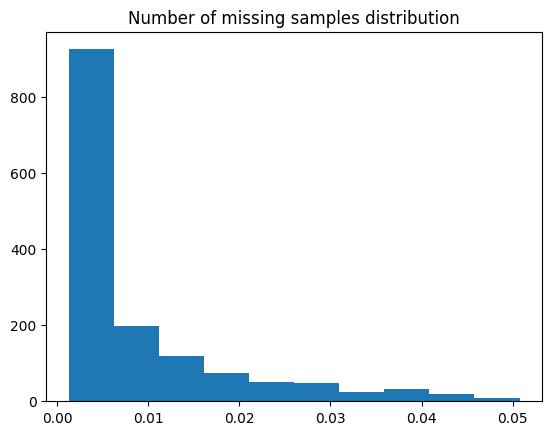

Begin imputing missing values with mean
End imputing missing values with mean


Hugo_Symbol,SAMPLE_ID,DAB1,TNNT2,C14orf181,TDRD6,RRS1,PTPRF,C6orf168,DSTYK,FAM163A,...,LRRC16A,PRKRIP1,UBN2,C8orf44,WHSC1L1,KIAA1432,AUH,ZNF189,PSMD5,MAPKAP1
0,TCGA-3C-AAAU-01,0.122480,0.422406,0.066364,0.964882,0.147498,0.515239,0.171413,0.030595,0.079985,...,0.079638,0.070722,0.080818,0.106777,0.128423,0.117556,0.089764,0.087979,0.164009,0.068373
1,TCGA-3C-AALI-01,0.144501,0.485900,0.065014,0.967061,0.621054,0.509700,0.296020,0.024533,0.292461,...,0.079638,0.041151,0.110590,0.090357,0.128423,0.117556,0.090575,0.114818,0.229552,0.055472
2,TCGA-3C-AALJ-01,0.198393,0.539556,0.069157,0.967570,0.161371,0.359982,0.462204,0.023208,0.371745,...,0.079638,0.070706,0.103455,0.054339,0.068559,0.144561,0.064580,0.083807,0.164009,0.058214
3,TCGA-3C-AALK-01,0.443030,0.464797,0.044753,0.978756,0.278852,0.325332,0.307525,0.021854,0.393587,...,0.079638,0.065418,0.151356,0.062123,0.128423,0.117556,0.092603,0.112266,0.164009,0.079971
4,TCGA-4H-AAAK-01,0.155328,0.436607,0.080718,0.957274,0.146726,0.352571,0.176244,0.025940,0.287001,...,0.079638,0.040739,0.137687,0.121221,0.128423,0.131233,0.071512,0.098672,0.164009,0.052626


In [8]:
df_methyl, nan_columns_methyl, missingness_columns_methyl = load_methylation_data(brca_data[1])
df_methyl.head()

In [9]:
print(f"Number of samples in df_methyl: {df_methyl.shape}")

Number of samples in df_methyl: (788, 16475)


## Copy Number Alteration (CNA) Data

In [10]:
def load_cna_data(data_path, mean_impute=True):
    
    # Dropping "Entrez_Gene_Id at the time of loading the data
    df_cna = pd.read_csv(data_path, sep = '\t').drop('Entrez_Gene_Id', axis = 1)
    
    # Setting Hugo_Symbol as the Index
    df_cna = df_cna.set_index('Hugo_Symbol').T
    
    # Are there any columns with all 0s
    count_nans = df_cna.isna().sum()
    print(f"Number of GENEs where all values are NaNs: {count_nans[count_nans==df_cna.shape[0]].shape[0]}")
    nan_columns = list(count_nans[count_nans==df_cna.shape[0]].index)
    
    # Are there any missing values
    print(f"Number of GENEs with missingness > 0: {count_nans[count_nans>0].shape[0]}")
    missingness_columns = list(count_nans[count_nans>0].index)
    
    if len(missingness_columns) > 0:
        plt.hist(count_nans[count_nans>0].values / len(df_cna))
        plt.title("Number of missing samples distribution")
        plt.show()
    
    
    if mean_impute:
        print(f"Begin imputing missing values with mean")
        df_cna.fillna(df_cna.mean(), inplace=True)
        print(f"End imputing missing values with mean")
    
    # Renaming the index as SAMPLE_ID and resetting_the index
    df_cna = df_cna.rename_axis('SAMPLE_ID').reset_index()
    
    return df_cna, nan_columns, missingness_columns

In [11]:
df_cna, nan_columns_cna, missingness_columns_cna = load_cna_data(brca_data[2], mean_impute=False)
df_cna.head()

Number of GENEs where all values are NaNs: 0
Number of GENEs with missingness > 0: 0


Hugo_Symbol,SAMPLE_ID,ACAP3,ACTRT2,AGRN,ANKRD65,ATAD3A,ATAD3B,ATAD3C,AURKAIP1,B3GALT6,...,SMIM9,SNORA36A,SNORA56,TMLHE,VBP1,IL9R|ENSG00000124334.12,SPRY3|ENSG00000168939.6,VAMP7|ENSG00000124333.10,WASH6P|ENSG00000182484.10,WASIR1|ENSG00000185203.7
0,TCGA-3C-AAAU-01,0,0,0,0,0,0,0,0,0,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
1,TCGA-3C-AALI-01,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
2,TCGA-3C-AALJ-01,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,0,0,0,0,0,0,0,0,0,0
3,TCGA-3C-AALK-01,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,TCGA-4H-AAAK-01,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
print(f"Number of samples in df_cna: {df_cna.shape}")

Number of samples in df_cna: (1080, 24777)


## Clinical Data

In [13]:
def load_clinical_data(data_path):
    
    #load the clinical data
    df_clinical = pd.read_csv(data_path, sep = '\t')
    
    # Selecting only the important columns
    df_clinical = df_clinical[['Patient ID', 'Sample ID', 'Overall Survival Status', 'Overall Survival (Months)']]
    
    # Renaming a couple of columns
    df_clinical = df_clinical.rename(columns = {'Patient ID': 'Patient_ID', 'Sample ID': 'SAMPLE_ID', 'Overall Survival Status':'OS_STATUS', 'Overall Survival (Months)':'OS_MONTHS'})
    
    # Updating OS_STATUS
    df_clinical['OS_STATUS'] = df_clinical['OS_STATUS'].apply(lambda x : 0 if str(x).find('LIVING') != -1 else 1)
    
    # Dropping OS_MONTHS data with Nan values
    df_clinical = df_clinical[~df_clinical['OS_MONTHS'].isna()]
    
    df_clinical = df_clinical.reset_index(drop = True)
    
    df_clinical.OS_MONTHS = df_clinical.OS_MONTHS.astype('float64')
    
    return df_clinical

In [14]:
df_clinical = load_clinical_data(brca_data[3])

In [15]:
df_clinical.head()

,Patient_ID,SAMPLE_ID,OS_STATUS,OS_MONTHS
0,TCGA-3C-AAAU,TCGA-3C-AAAU-01,0,132.95
1,TCGA-3C-AALI,TCGA-3C-AALI-01,0,131.57
2,TCGA-3C-AALJ,TCGA-3C-AALJ-01,0,48.42
3,TCGA-3C-AALK,TCGA-3C-AALK-01,0,47.57
4,TCGA-4H-AAAK,TCGA-4H-AAAK-01,0,11.43


In [16]:
df_clinical.dtypes

Patient_ID     object
SAMPLE_ID      object
OS_STATUS       int64
OS_MONTHS     float64
dtype: object

In [17]:
df_clinical.shape

(1103, 4)

---

# Pathway

---

In [18]:
import pandas as pd
pathways_data = pd.read_csv(f"kegg_pathway_data/pathway_db2.csv")

pathways_data.head()

,0,1,2,3,4,5,6,7,8,9,...,438,439,440,441,442,443,444,445,446,447
0,KEGG_GLYCOLYSIS_/_GLUCONEOGENESIS,ALDOB,ENO3,LDHB,PGAM4,ALDH3B2,ADH5,AKR1A1,LDHAL6B,MINPP1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,KEGG_CITRATE_CYCLE_(TCA_CYCLE),SUCLA2,IDH1,SDHA,ACO2,OGDH,SUCLG1,ACLY,OGDHL,PDHA1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,KEGG_PENTOSE_PHOSPHATE_PATHWAY,ALDOB,PRPS1L1,PGD,H6PD,PGLS,PRPS1,GLYCTK,SHPK,RBKS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,KEGG_PENTOSE_AND_GLUCURONATE_INTERCONVERSIONS,UGT1A6,DHDH,UGT2A1,AKR1A1,UGT1A1,SORD,DCXR,UGT1A3,UGT2B28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM,MPI,ALDOB,PFKFB2,PMM2,GMPPA,SORD,PFKP,PFKFB4,FBP2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
pathways_data.shape

(257, 448)

In [20]:
# exclude large (i.e. > 300) AND small (i.e. < 15) pathways 
'''Exclude small and large sizes of pathways'''
def pathway_filter(pathways_data, small_cutoff, large_cutoff):
    # minus first column (i.e. pathway_name)
    pathway_sizes = pathways_data.count(axis=1) - 1
    pathways = pathways_data[(pathway_sizes > small_cutoff) & (pathway_sizes < large_cutoff)]
    return(pathways)

pathways = pathway_filter(pathways_data, 15, 300)
print("Number of pathways with length between 15 and 300: ", pathways.shape[0])

# Reset Indices
pathways = pathways.reset_index(drop=True)

# Dropping Columns with All NaN values after filtering pathways
pathways = pathways.dropna(axis=1, how='all')

# Correcting column names
pathways.columns = range(pathways.shape[1])

# Renaming 0th column as Pathway
pathways = pathways.rename(columns={0:'Pathway'})

# .head() of final pathways
pathways.head()

Number of pathways with length between 15 and 300:  231


,Pathway,1,2,3,4,5,6,7,8,9,...,289,290,291,292,293,294,295,296,297,298
0,KEGG_GLYCOLYSIS_/_GLUCONEOGENESIS,ALDOB,ENO3,LDHB,PGAM4,ALDH3B2,ADH5,AKR1A1,LDHAL6B,MINPP1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,KEGG_CITRATE_CYCLE_(TCA_CYCLE),SUCLA2,IDH1,SDHA,ACO2,OGDH,SUCLG1,ACLY,OGDHL,PDHA1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,KEGG_PENTOSE_PHOSPHATE_PATHWAY,ALDOB,PRPS1L1,PGD,H6PD,PGLS,PRPS1,GLYCTK,SHPK,RBKS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,KEGG_PENTOSE_AND_GLUCURONATE_INTERCONVERSIONS,UGT1A6,DHDH,UGT2A1,AKR1A1,UGT1A1,SORD,DCXR,UGT1A3,UGT2B28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM,MPI,ALDOB,PFKFB2,PMM2,GMPPA,SORD,PFKP,PFKFB4,FBP2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
pathway_name = pathways['Pathway']
pathway_name

0                      KEGG_GLYCOLYSIS_/_GLUCONEOGENESIS
1                         KEGG_CITRATE_CYCLE_(TCA_CYCLE)
2                         KEGG_PENTOSE_PHOSPHATE_PATHWAY
3          KEGG_PENTOSE_AND_GLUCURONATE_INTERCONVERSIONS
4                   KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM
                             ...                        
226                    KEGG_LONGEVITY_REGULATING_PATHWAY
227    KEGG_LONGEVITY_REGULATING_PATHWAY_-_MULTIPLE_S...
228                                KEGG_CIRCADIAN_RHYTHM
229                           KEGG_CIRCADIAN_ENTRAINMENT
230                                   KEGG_THERMOGENESIS
Name: Pathway, Length: 231, dtype: object

In [22]:
set_pathway = {'pathway':[], 'gene':[]}
def make_pathway_set(pathway_df):
    set_pathway['pathway'].append(pathway_df[~pathway_df.isna()].Pathway)
    set_pathway['gene'].append(pathway_df[~pathway_df.isna()][1:])

pathways.apply(make_pathway_set, 1)

0      None
1      None
2      None
3      None
4      None
       ... 
226    None
227    None
228    None
229    None
230    None
Length: 231, dtype: object

In [23]:
import numpy as np

In [24]:
pathway_list = np.concatenate(pathways.iloc[:, 1:].values.astype('str'), axis=None)
pathway_list

array(['ALDOB', 'ENO3', 'LDHB', ..., 'nan', 'nan', 'nan'], dtype='<U15')

In [25]:
pathway_list.size

68838

In [26]:
np.unique(pathway_list), np.unique(pathway_list).size 

(array(['A2M', 'A3GALT2', 'A4GALT', ..., 'ZNRF3', 'ZYX', 'nan'],
       dtype='<U15'),
 7224)

In [27]:
unique_gene_in_pathway = np.delete(np.unique(pathway_list), np.where(np.unique(pathway_list)=='nan'))
unique_gene_in_pathway

array(['A2M', 'A3GALT2', 'A4GALT', ..., 'ZNHIT1', 'ZNRF3', 'ZYX'],
      dtype='<U15')

In [28]:
'FLT3' in unique_gene_in_pathway

True

In [29]:
unique_gene_in_pathway.size

7223

---

## Ensure that GENEs in mRNA are populated in DNA and CNA

In [30]:
# Change the list of all unique genes in Pathway to Object type
unique_gene_in_pathway = unique_gene_in_pathway.astype(object)

In [31]:
df_exp.shape, df_methyl.shape, df_cna.shape

((1100, 20213), (788, 16475), (1080, 24777))

In [32]:
genes_to_drop_exp = list(set(df_exp.columns[1:]).difference(set(unique_gene_in_pathway)))
df_exp = df_exp.drop(genes_to_drop_exp, axis=1)
df_exp.head()

Hugo_Symbol,SAMPLE_ID,A2M,AAAS,AACS,AADAT,AANAT,AARS2,AASDHPPT,AASS,ABAT,...,ZMPSTE24,ZNF143,ZNF274,ZNF385A,ZNF516,ZNF76,ZNFX1,ZNHIT1,ZNRF3,ZYX
0,TCGA-3C-AAAU-01,-0.9584,-0.2155,0.1769,-1.7770,-0.7935,1.1838,-0.0285,-1.6648,-0.1332,...,0.4867,0.7884,-0.5446,-0.2052,1.3570,0.6336,-0.1889,-0.3538,1.2856,0.0077
1,TCGA-3C-AALI-01,-0.5741,0.8255,-0.3945,-0.5373,1.7946,0.1707,-0.4719,-1.0813,-0.8503,...,-2.2031,-0.3008,-1.5938,1.2525,-1.8470,1.2804,0.3560,1.2492,0.1645,0.9335
2,TCGA-3C-AALJ-01,-0.3511,0.1441,0.9249,0.1542,1.4301,-0.0218,-0.1214,-1.0040,-0.5136,...,-2.1267,-1.1390,0.2706,0.9741,-1.2112,-0.0348,-1.1744,1.1303,-0.4431,0.9163
3,TCGA-3C-AALK-01,-0.0415,0.3814,-0.3386,0.2124,-0.6428,-0.0695,-0.5220,0.1486,0.6390,...,-0.7506,-0.0136,0.3481,0.7387,0.4739,0.5981,-0.8679,0.4004,-0.0372,1.0020
4,TCGA-4H-AAAK-01,-0.2346,0.5571,-0.3850,0.3001,-0.6177,0.7093,-1.4252,1.1307,0.1071,...,-1.2354,-0.4785,-0.0478,0.0584,0.4055,0.3299,-0.4042,0.0366,0.0807,0.2990


In [33]:
genes_to_drop_methyl = list(set(df_methyl.columns[1:]).difference(set(unique_gene_in_pathway)))
df_methyl = df_methyl.drop(genes_to_drop_methyl, axis=1)
df_methyl.head()

Hugo_Symbol,SAMPLE_ID,TNNT2,PTPRF,MMACHC,MED13,DAZAP1,WIPF2,ACSL5,KCNJ9,VPS28,...,UBE2L3,DEPDC5,NAGA,SF3B1,ASXL2,BIRC6,PIGG,WDFY3,AUH,MAPKAP1
0,TCGA-3C-AAAU-01,0.422406,0.515239,0.342131,0.060207,0.876136,0.045075,0.188244,0.723469,0.038903,...,0.107087,0.090520,0.106143,0.12845,0.107960,0.052366,0.17619,0.09769,0.089764,0.068373
1,TCGA-3C-AALI-01,0.485900,0.509700,0.931128,0.042951,0.923037,0.045496,0.037945,0.334278,0.033211,...,0.187368,0.135144,0.189644,0.12845,0.107797,0.052366,0.17619,0.09769,0.090575,0.055472
2,TCGA-3C-AALJ-01,0.539556,0.359982,0.766751,0.038674,0.874467,0.025337,0.370267,0.564296,0.027002,...,0.107087,0.090520,0.106143,0.12845,0.108547,0.052366,0.17619,0.09769,0.064580,0.058214
3,TCGA-3C-AALK-01,0.464797,0.325332,0.743736,0.024993,0.896860,0.039656,0.171662,0.814294,0.029662,...,0.145784,0.148650,0.106143,0.12845,0.151005,0.052366,0.17619,0.09769,0.092603,0.079971
4,TCGA-4H-AAAK-01,0.436607,0.352571,0.751859,0.054251,0.869391,0.038324,0.082349,0.749459,0.031910,...,0.132327,0.131349,0.128863,0.12845,0.160891,0.052366,0.17619,0.09769,0.071512,0.052626


In [34]:
genes_to_drop_cna = list(set(df_cna.columns[1:]).difference(set(unique_gene_in_pathway)))
df_cna = df_cna.drop(genes_to_drop_cna, axis=1)
df_cna.head()

Hugo_Symbol,SAMPLE_ID,ACAP3,AGRN,B3GALT6,CALML6,DVL1,GABRD,GNB1,HES5,ISG15,...,ATP6AP1,PLXNA3,UBL4A,G6PD,IKBKG,BRCC3,DKC1,F8,RAB39B,TMLHE
0,TCGA-3C-AAAU-01,0,0,0,0,0,0,0,0,0,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
1,TCGA-3C-AALI-01,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
2,TCGA-3C-AALJ-01,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,0,0,0,0,0,0,0,0,0,0
3,TCGA-3C-AALK-01,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,TCGA-4H-AAAK-01,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [35]:
df_exp.shape, df_methyl.shape, df_cna.shape

((1100, 6355), (788, 5770), (1080, 6706))

In [36]:
df_exp.head()

Hugo_Symbol,SAMPLE_ID,A2M,AAAS,AACS,AADAT,AANAT,AARS2,AASDHPPT,AASS,ABAT,...,ZMPSTE24,ZNF143,ZNF274,ZNF385A,ZNF516,ZNF76,ZNFX1,ZNHIT1,ZNRF3,ZYX
0,TCGA-3C-AAAU-01,-0.9584,-0.2155,0.1769,-1.7770,-0.7935,1.1838,-0.0285,-1.6648,-0.1332,...,0.4867,0.7884,-0.5446,-0.2052,1.3570,0.6336,-0.1889,-0.3538,1.2856,0.0077
1,TCGA-3C-AALI-01,-0.5741,0.8255,-0.3945,-0.5373,1.7946,0.1707,-0.4719,-1.0813,-0.8503,...,-2.2031,-0.3008,-1.5938,1.2525,-1.8470,1.2804,0.3560,1.2492,0.1645,0.9335
2,TCGA-3C-AALJ-01,-0.3511,0.1441,0.9249,0.1542,1.4301,-0.0218,-0.1214,-1.0040,-0.5136,...,-2.1267,-1.1390,0.2706,0.9741,-1.2112,-0.0348,-1.1744,1.1303,-0.4431,0.9163
3,TCGA-3C-AALK-01,-0.0415,0.3814,-0.3386,0.2124,-0.6428,-0.0695,-0.5220,0.1486,0.6390,...,-0.7506,-0.0136,0.3481,0.7387,0.4739,0.5981,-0.8679,0.4004,-0.0372,1.0020
4,TCGA-4H-AAAK-01,-0.2346,0.5571,-0.3850,0.3001,-0.6177,0.7093,-1.4252,1.1307,0.1071,...,-1.2354,-0.4785,-0.0478,0.0584,0.4055,0.3299,-0.4042,0.0366,0.0807,0.2990


In [37]:
# df_exp.columns[2:]

In [38]:
exp_only_genes = list(set(df_exp.columns[1:]))
len(exp_only_genes)

6353

In [39]:
#exp_only_genes

In [40]:
# Populating missing genes from exp_only_genes in df_methyl
missing_genes_in_methyl = [gene for gene in exp_only_genes if gene not in df_methyl.columns]

for gene in missing_genes_in_methyl:
    df_methyl[gene] = 0
    
# Select only exp_only_genes
df_methyl = df_methyl[["SAMPLE_ID" ] + exp_only_genes]

In [41]:
# Populating missing genes from exp_only_genes in df_cna
missing_genes_in_cna = [gene for gene in exp_only_genes if gene not in df_cna.columns]

for gene in missing_genes_in_cna:
    df_cna[gene] = 0
    
df_cna = df_cna[["SAMPLE_ID" ] + exp_only_genes]

In [42]:
df_exp = df_exp.loc[:, ~df_exp.columns.duplicated(keep='first')]
df_methyl = df_methyl.loc[:, ~df_methyl.columns.duplicated(keep='first')]
df_cna = df_cna.loc[:, ~df_cna.columns.duplicated(keep='first')]

In [43]:
df_exp.shape, df_methyl.shape, df_cna.shape

((1100, 6354), (788, 6354), (1080, 6354))

In [44]:
set(list(df_methyl.columns)).difference(set(list(df_exp.columns)))

set()

In [45]:
set(list(df_exp.columns)).difference(set(list(df_methyl.columns)))

set()

In [46]:
# Populating missing genes from exp_only_genes in df_methyl
missing_genes_in_methyl = [gene for gene in exp_only_genes if gene not in df_methyl.columns]

len(missing_genes_in_methyl)

0

In [47]:
# Populating missing genes from exp_only_genes in df_cna
missing_genes_in_cna = [gene for gene in exp_only_genes if gene not in df_cna.columns]

len(missing_genes_in_cna)

0

In [48]:
df_exp.shape, df_methyl.shape, df_cna.shape

((1100, 6354), (788, 6354), (1080, 6354))

In [49]:
final_df_exp = df_exp.add_suffix('_e')
final_df_exp = final_df_exp.rename(columns = {'SAMPLE_ID_e' : 'SAMPLE_ID'})
final_df_exp.head()

Hugo_Symbol,SAMPLE_ID,A2M_e,AAAS_e,AACS_e,AADAT_e,AANAT_e,AARS2_e,AASDHPPT_e,AASS_e,ABAT_e,...,ZMPSTE24_e,ZNF143_e,ZNF274_e,ZNF385A_e,ZNF516_e,ZNF76_e,ZNFX1_e,ZNHIT1_e,ZNRF3_e,ZYX_e
0,TCGA-3C-AAAU-01,-0.9584,-0.2155,0.1769,-1.7770,-0.7935,1.1838,-0.0285,-1.6648,-0.1332,...,0.4867,0.7884,-0.5446,-0.2052,1.3570,0.6336,-0.1889,-0.3538,1.2856,0.0077
1,TCGA-3C-AALI-01,-0.5741,0.8255,-0.3945,-0.5373,1.7946,0.1707,-0.4719,-1.0813,-0.8503,...,-2.2031,-0.3008,-1.5938,1.2525,-1.8470,1.2804,0.3560,1.2492,0.1645,0.9335
2,TCGA-3C-AALJ-01,-0.3511,0.1441,0.9249,0.1542,1.4301,-0.0218,-0.1214,-1.0040,-0.5136,...,-2.1267,-1.1390,0.2706,0.9741,-1.2112,-0.0348,-1.1744,1.1303,-0.4431,0.9163
3,TCGA-3C-AALK-01,-0.0415,0.3814,-0.3386,0.2124,-0.6428,-0.0695,-0.5220,0.1486,0.6390,...,-0.7506,-0.0136,0.3481,0.7387,0.4739,0.5981,-0.8679,0.4004,-0.0372,1.0020
4,TCGA-4H-AAAK-01,-0.2346,0.5571,-0.3850,0.3001,-0.6177,0.7093,-1.4252,1.1307,0.1071,...,-1.2354,-0.4785,-0.0478,0.0584,0.4055,0.3299,-0.4042,0.0366,0.0807,0.2990


In [50]:
df_methyl = df_methyl[list(df_exp.columns)]
final_df_methyl = df_methyl.add_suffix('_m')
final_df_methyl = final_df_methyl.rename(columns = {'SAMPLE_ID_m' : 'SAMPLE_ID'})

final_df_methyl.head()

Hugo_Symbol,SAMPLE_ID,A2M_m,AAAS_m,AACS_m,AADAT_m,AANAT_m,AARS2_m,AASDHPPT_m,AASS_m,ABAT_m,...,ZMPSTE24_m,ZNF143_m,ZNF274_m,ZNF385A_m,ZNF516_m,ZNF76_m,ZNFX1_m,ZNHIT1_m,ZNRF3_m,ZYX_m
0,TCGA-3C-AAAU-01,0.939477,0.029767,0.097124,0.079312,0.652483,0.895773,0.030000,0.083430,0.551592,...,0.023534,0.039020,0.202412,0.359479,0.757824,0.148852,0.032739,0.031721,0.278262,0.903208
1,TCGA-3C-AALI-01,0.783152,0.023413,0.504042,0.070529,0.695340,0.902614,0.022059,0.061005,0.810849,...,0.028040,0.040388,0.539708,0.318822,0.698718,0.180526,0.021305,0.030197,0.935430,0.913747
2,TCGA-3C-AALJ-01,0.935178,0.032650,0.118826,0.109128,0.774939,0.888786,0.016223,0.134619,0.792817,...,0.023871,0.040095,0.149180,0.230625,0.853522,0.233470,0.031260,0.037414,0.670070,0.902455
3,TCGA-3C-AALK-01,0.900909,0.028248,0.299652,0.261271,0.657552,0.920098,0.022123,0.104958,0.607932,...,0.025796,0.040046,0.306841,0.407261,0.770105,0.260419,0.025449,0.026546,0.787021,0.799299
4,TCGA-4H-AAAK-01,0.910596,0.022789,0.201803,0.057823,0.669746,0.909870,0.026674,0.047654,0.708260,...,0.025642,0.033156,0.141641,0.395477,0.471544,0.314584,0.026680,0.039415,0.781058,0.882382


In [51]:
df_cna = df_cna[list(df_exp.columns)]
final_df_cna = df_cna.add_suffix('_c')
final_df_cna = final_df_cna.rename(columns = {'SAMPLE_ID_c' : 'SAMPLE_ID'})
final_df_cna.head()

Hugo_Symbol,SAMPLE_ID,A2M_c,AAAS_c,AACS_c,AADAT_c,AANAT_c,AARS2_c,AASDHPPT_c,AASS_c,ABAT_c,...,ZMPSTE24_c,ZNF143_c,ZNF274_c,ZNF385A_c,ZNF516_c,ZNF76_c,ZNFX1_c,ZNHIT1_c,ZNRF3_c,ZYX_c
0,TCGA-3C-AAAU-01,1,-1,-1,-1,0,1,-1,1,0,...,0,1,0,-1,1,1,0,1,-1,1
1,TCGA-3C-AALI-01,0,0,0,0,1,0,0,1,0,...,-1,0,0,0,-1,0,1,1,1,1
2,TCGA-3C-AALJ-01,0,-1,1,-1,1,-1,-1,0,0,...,-1,0,0,-1,1,-1,2,0,-1,0
3,TCGA-3C-AALK-01,0,0,0,0,2,0,-1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,TCGA-4H-AAAK-01,-1,0,0,0,1,0,-1,0,0,...,0,0,1,0,0,0,0,0,0,0


final_df_exp.shape, final_df_methyl.shape, final_df_cna.shape, df_clinical.shape## Merge 4 Data into 1 DataSet

In [52]:
final_df_exp.shape, final_df_methyl.shape, final_df_cna.shape, df_clinical.shape

((1100, 6354), (788, 6354), (1080, 6354), (1103, 4))

In [53]:
merged_df = pd.merge(final_df_exp, final_df_methyl, how = 'inner', on = 'SAMPLE_ID')

In [54]:
merged_df

Hugo_Symbol,SAMPLE_ID,A2M_e,AAAS_e,AACS_e,AADAT_e,AANAT_e,AARS2_e,AASDHPPT_e,AASS_e,ABAT_e,...,ZMPSTE24_m,ZNF143_m,ZNF274_m,ZNF385A_m,ZNF516_m,ZNF76_m,ZNFX1_m,ZNHIT1_m,ZNRF3_m,ZYX_m
0,TCGA-3C-AAAU-01,-0.9584,-0.2155,0.1769,-1.7770,-0.7935,1.1838,-0.0285,-1.6648,-0.1332,...,0.023534,0.039020,0.202412,0.359479,0.757824,0.148852,0.032739,0.031721,0.278262,0.903208
1,TCGA-3C-AALI-01,-0.5741,0.8255,-0.3945,-0.5373,1.7946,0.1707,-0.4719,-1.0813,-0.8503,...,0.028040,0.040388,0.539708,0.318822,0.698718,0.180526,0.021305,0.030197,0.935430,0.913747
2,TCGA-3C-AALJ-01,-0.3511,0.1441,0.9249,0.1542,1.4301,-0.0218,-0.1214,-1.0040,-0.5136,...,0.023871,0.040095,0.149180,0.230625,0.853522,0.233470,0.031260,0.037414,0.670070,0.902455
3,TCGA-3C-AALK-01,-0.0415,0.3814,-0.3386,0.2124,-0.6428,-0.0695,-0.5220,0.1486,0.6390,...,0.025796,0.040046,0.306841,0.407261,0.770105,0.260419,0.025449,0.026546,0.787021,0.799299
4,TCGA-4H-AAAK-01,-0.2346,0.5571,-0.3850,0.3001,-0.6177,0.7093,-1.4252,1.1307,0.1071,...,0.025642,0.033156,0.141641,0.395477,0.471544,0.314584,0.026680,0.039415,0.781058,0.882382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
780,TCGA-WT-AB44-01,-1.0585,2.0069,-0.9541,-0.3312,-1.6857,0.7600,-0.3339,1.5091,0.1886,...,0.027102,0.033154,0.140488,0.598951,0.494549,0.337760,0.030875,0.030473,0.910582,0.867351
781,TCGA-XX-A899-01,0.8496,0.0678,0.3114,-0.0668,0.6634,-0.0122,-0.9240,1.5287,0.4192,...,0.021853,0.029091,0.200816,0.482225,0.520182,0.286284,0.021228,0.041185,0.901002,0.887544
782,TCGA-XX-A89A-01,0.5986,0.8767,-0.3297,0.0070,0.3179,1.0563,-1.3761,-0.0408,-0.1584,...,0.015676,0.032101,0.119796,0.411377,0.613125,0.297825,0.023846,0.070945,0.682003,0.904809
783,TCGA-Z7-A8R5-01,1.7044,1.3624,0.1268,-0.1040,-1.6857,-0.1262,-1.3674,0.5273,-0.3254,...,0.017883,0.041420,0.328216,0.485325,0.641884,0.194346,0.025088,0.029802,0.757665,0.873796


In [55]:
merged_df = pd.merge(merged_df, final_df_cna, how='inner', on='SAMPLE_ID')
merged_df

Hugo_Symbol,SAMPLE_ID,A2M_e,AAAS_e,AACS_e,AADAT_e,AANAT_e,AARS2_e,AASDHPPT_e,AASS_e,ABAT_e,...,ZMPSTE24_c,ZNF143_c,ZNF274_c,ZNF385A_c,ZNF516_c,ZNF76_c,ZNFX1_c,ZNHIT1_c,ZNRF3_c,ZYX_c
0,TCGA-3C-AAAU-01,-0.9584,-0.2155,0.1769,-1.7770,-0.7935,1.1838,-0.0285,-1.6648,-0.1332,...,0,1,0,-1,1,1,0,1,-1,1
1,TCGA-3C-AALI-01,-0.5741,0.8255,-0.3945,-0.5373,1.7946,0.1707,-0.4719,-1.0813,-0.8503,...,-1,0,0,0,-1,0,1,1,1,1
2,TCGA-3C-AALJ-01,-0.3511,0.1441,0.9249,0.1542,1.4301,-0.0218,-0.1214,-1.0040,-0.5136,...,-1,0,0,-1,1,-1,2,0,-1,0
3,TCGA-3C-AALK-01,-0.0415,0.3814,-0.3386,0.2124,-0.6428,-0.0695,-0.5220,0.1486,0.6390,...,0,0,0,0,0,0,0,0,0,0
4,TCGA-4H-AAAK-01,-0.2346,0.5571,-0.3850,0.3001,-0.6177,0.7093,-1.4252,1.1307,0.1071,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
765,TCGA-WT-AB44-01,-1.0585,2.0069,-0.9541,-0.3312,-1.6857,0.7600,-0.3339,1.5091,0.1886,...,-1,0,-1,0,-1,0,-1,1,-1,1
766,TCGA-XX-A899-01,0.8496,0.0678,0.3114,-0.0668,0.6634,-0.0122,-0.9240,1.5287,0.4192,...,0,0,0,0,0,0,0,0,0,0
767,TCGA-XX-A89A-01,0.5986,0.8767,-0.3297,0.0070,0.3179,1.0563,-1.3761,-0.0408,-0.1584,...,2,0,0,0,-1,0,0,0,-1,0
768,TCGA-Z7-A8R5-01,1.7044,1.3624,0.1268,-0.1040,-1.6857,-0.1262,-1.3674,0.5273,-0.3254,...,-1,-1,0,1,0,1,0,0,-1,0


In [56]:
merged_multi_omics = pd.merge(merged_df, df_clinical, how='inner', on='SAMPLE_ID')

In [57]:
merged_multi_omics.head()

,SAMPLE_ID,A2M_e,AAAS_e,AACS_e,AADAT_e,AANAT_e,AARS2_e,AASDHPPT_e,AASS_e,ABAT_e,...,ZNF385A_c,ZNF516_c,ZNF76_c,ZNFX1_c,ZNHIT1_c,ZNRF3_c,ZYX_c,Patient_ID,OS_STATUS,OS_MONTHS
0,TCGA-3C-AAAU-01,-0.9584,-0.2155,0.1769,-1.7770,-0.7935,1.1838,-0.0285,-1.6648,-0.1332,...,-1,1,1,0,1,-1,1,TCGA-3C-AAAU,0,132.95
1,TCGA-3C-AALI-01,-0.5741,0.8255,-0.3945,-0.5373,1.7946,0.1707,-0.4719,-1.0813,-0.8503,...,0,-1,0,1,1,1,1,TCGA-3C-AALI,0,131.57
2,TCGA-3C-AALJ-01,-0.3511,0.1441,0.9249,0.1542,1.4301,-0.0218,-0.1214,-1.0040,-0.5136,...,-1,1,-1,2,0,-1,0,TCGA-3C-AALJ,0,48.42
3,TCGA-3C-AALK-01,-0.0415,0.3814,-0.3386,0.2124,-0.6428,-0.0695,-0.5220,0.1486,0.6390,...,0,0,0,0,0,0,0,TCGA-3C-AALK,0,47.57
4,TCGA-4H-AAAK-01,-0.2346,0.5571,-0.3850,0.3001,-0.6177,0.7093,-1.4252,1.1307,0.1071,...,0,0,0,0,0,0,0,TCGA-4H-AAAK,0,11.43


In [58]:
merged_multi_omics.shape

(769, 19063)

In [59]:
exp_cols = [col for col in merged_multi_omics if "_e" in col]
len(exp_cols)

6353

In [60]:
methyl_cols = [col for col in merged_multi_omics if "_m" in col]
len(methyl_cols)

6353

In [61]:
cna_cols = [col for col in merged_multi_omics if "_c" in col]
len(cna_cols)

6353

In [62]:
6353+6353+6353

19059

In [63]:
[col for col in merged_multi_omics.columns if col in df_clinical.columns]

['SAMPLE_ID', 'Patient_ID', 'OS_STATUS', 'OS_MONTHS']

In [64]:
(len(df_exp.columns)-1)*3 + 4

19063

In [66]:
merged_multi_omics.to_csv(f"processed_{cancer_type}/{cancer_type}_merged_multi_omics.csv", index=False)

## Mask between gene and pathway

In [67]:
from scipy import sparse

In [68]:
pathway_name.size, len(df_exp.columns[1:])

(231, 6353)

In [69]:
common_genes = list(df_exp.columns[1:])

In [70]:
pathway_sparse_mat = sparse.coo_matrix((pathway_name.size, len(common_genes))).toarray()
pathway_sparse_mat.shape

(231, 6353)

In [71]:
for i in range(len(pathway_name)):
    pathway_sparse_mat[i, np.argwhere(np.isin(common_genes, set_pathway['gene'][i])).reshape((-1, ))] = 1.
            
pathway_sparse_mat, pathway_sparse_mat.shape

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 (231, 6353))

In [72]:
pathway_mat_df = pd.DataFrame(pathway_sparse_mat, columns=common_genes)
pathway_mat_df.index = pathway_name
pathway_mat_df.head()

,A2M,AAAS,AACS,AADAT,AANAT,AARS2,AASDHPPT,AASS,ABAT,ABCA10,...,ZMPSTE24,ZNF143,ZNF274,ZNF385A,ZNF516,ZNF76,ZNFX1,ZNHIT1,ZNRF3,ZYX
Pathway,,,,,,,,,,,,,,,,,,,,,
KEGG_GLYCOLYSIS_/_GLUCONEOGENESIS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
KEGG_CITRATE_CYCLE_(TCA_CYCLE),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
KEGG_PENTOSE_PHOSPHATE_PATHWAY,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
KEGG_PENTOSE_AND_GLUCURONATE_INTERCONVERSIONS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [73]:
sum(pathway_mat_df.sum()==0)

0

In [74]:
pathway_mat_df.to_csv(f"processed_{cancer_type}/{cancer_type}_pathway_mask.csv")

In [75]:
pathway_sparse_mat.sum()

17946.0

In [77]:
pathway_sparse_mat = sparse.coo_matrix(pathway_sparse_mat)

sparse.save_npz(f"processed_{cancer_type}/{cancer_type}_gene_pathway_mask.npz", pathway_sparse_mat)

In [78]:
import pickle

with open(f"processed_{cancer_type}/{cancer_type}_gene_columns.pickle", "wb") as file:
    pickle.dump(common_genes, file)

In [79]:
final_df_exp.to_csv(f"processed_{cancer_type}/{cancer_type}_exp.csv", index=False)
final_df_methyl.to_csv(f"processed_{cancer_type}/{cancer_type}_methyl.csv", index=False)
final_df_cna.to_csv(f"processed_{cancer_type}/{cancer_type}_cna.csv", index=False)

In [80]:
pathway_sparse_mat.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [81]:
# Check for duplicate rows
# np.all checks if all elements in an axis are True when comparing rows, np.any to see if any such rows exist
duplicates = np.any(np.all(pathway_sparse_mat.toarray()[:, None] == pathway_sparse_mat.toarray(), axis=2).sum(axis=0) > 1)

print("Are there any duplicate rows?:", duplicates)

Are there any duplicate rows?: False
